In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Epoch 1/50, Loss: 0.10825198143720627
Epoch 2/50, Loss: 0.001151052420027554
Epoch 3/50, Loss: 0.001269070548005402
Epoch 4/50, Loss: 0.0009817383252084255
Epoch 5/50, Loss: 0.0010608891025185585
Epoch 6/50, Loss: 0.0014484681887552142
Epoch 7/50, Loss: 0.001434006029739976
Epoch 8/50, Loss: 0.0012691443553194404
Epoch 9/50, Loss: 0.0011444586561992764
Epoch 10/50, Loss: 0.0010613714111968875
Epoch 11/50, Loss: 0.0010199842508882284
Epoch 12/50, Loss: 0.0010097644990310073
Epoch 13/50, Loss: 0.0010145566193386912
Epoch 14/50, Loss: 0.0010281519498676062
Epoch 15/50, Loss: 0.0010411491384729743
Epoch 16/50, Loss: 0.001045877579599619
Epoch 17/50, Loss: 0.0010352442041039467
Epoch 18/50, Loss: 0.0010059846099466085
Epoch 19/50, Loss: 0.0009583787177689373
Epoch 20/50, Loss: 0.0008971437928266823
Epoch 21/50, Loss: 0.0008292507263831794
Epoch 22/50, Loss: 0.0007619668613187969
Epoch 23/50, Loss: 0.0007007011445239186
Epoch 24/50, Loss: 0.0006483032484538853
Epoch 25/50, Loss: 0.0006052675

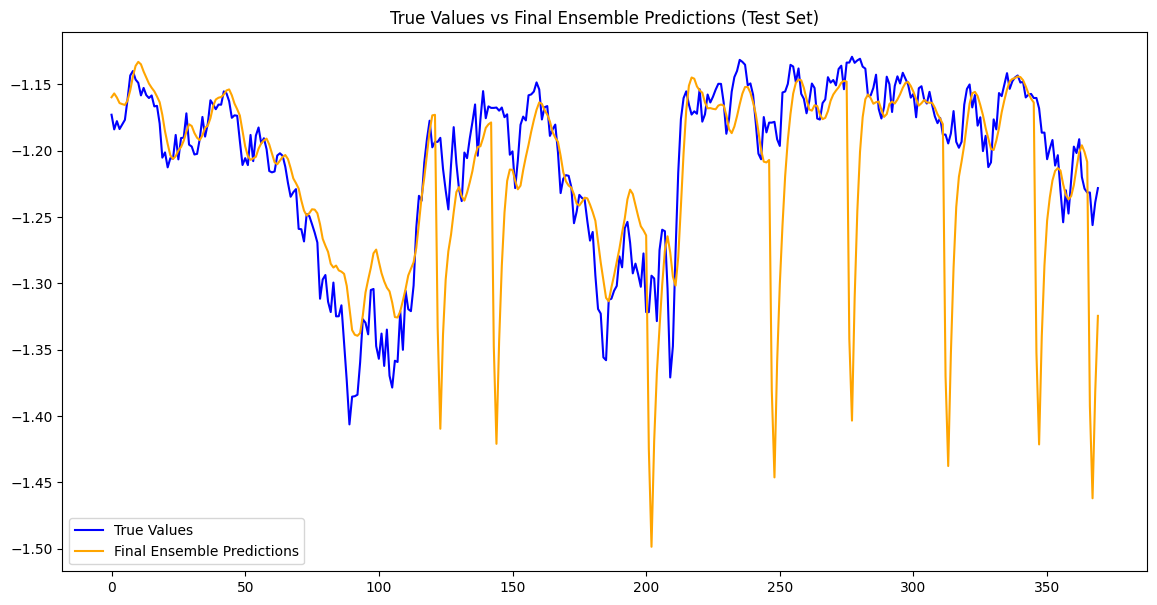

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Function to get stock data
def get_data(symbol, start_date, end_date):
    df = pd.read_csv('/content/drive/MyDrive/side project 1/S&P 500 (2015- 8 Jan 2025).csv')
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')  # Convert to datetime
    df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]  # Filter by date range
    return df

# StockDataset Class
class StockDataset(torch.utils.data.Dataset):
    def __init__(self, symbol, start_date, end_date, look_back=60):
        self.symbol = symbol
        self.start_date = start_date
        self.end_date = end_date
        self.look_back = look_back
        self.raw_data = get_data(symbol, start_date, end_date)
        self.raw_data = self.raw_data[['Close', 'Open', 'Low', 'High']].values

        # Calculate MACD
        self.raw_data = self._calculate_macd(self.raw_data)

        # Z-score normalization
        self.scaler = StandardScaler()
        self.raw_data = self.scaler.fit_transform(self.raw_data)

        self.X, self.y = self._get_all_training(self.raw_data, look_back)

    def _calculate_macd(self, data):
        close_prices = data[:, 0]  # Assuming 'Close' is the first column
        short_ema = pd.Series(close_prices).ewm(span=12, adjust=False).mean().to_numpy()
        long_ema = pd.Series(close_prices).ewm(span=26, adjust=False).mean().to_numpy()
        macd = short_ema - long_ema
        signal = pd.Series(macd).ewm(span=9, adjust=False).mean().to_numpy()

        # Append MACD and Signal Line to raw_data
        return np.column_stack((data, macd, signal))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def _get_all_training(self, raw_data, look_back):
        X = []
        y = []
        lenX = len(raw_data)
        for i_data in range(lenX - look_back - 1):
            X_temp = raw_data[i_data:i_data + look_back, :]
            X.append(torch.tensor(X_temp).float())
            y_temp = raw_data[i_data + look_back, 0]  # Target is 'Close' price
            y.append(torch.tensor(y_temp).float())
        return X, y

# LSTM Model Class
class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=6, hidden_size=50, num_layers=1, batch_first=True)
        self.fc = nn.Linear(50, 1)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.fc(x[:, -1, :])  # Take the last time step
        return x

    def predict(self, X):
        self.eval()  # Set the model to evaluation mode
        with torch.no_grad():
            return self.forward(X).numpy()

# KNN Model Class
class KNNModel:
    def __init__(self):
        self.model = KNeighborsRegressor(n_neighbors=5)

    def train(self, X_train, y_train):
        self.model.fit(X_train.reshape(X_train.shape[0], -1), y_train)

    def predict(self, X):
        return self.model.predict(X.reshape(X.shape[0], -1))

# Random Forest Model Class
class RFModel:
    def __init__(self):
        self.model = RandomForestRegressor(n_estimators=100)

    def train(self, X_train, y_train):
        self.model.fit(X_train.reshape(X_train.shape[0], -1), y_train)

    def predict(self, X):
        return self.model.predict(X.reshape(X.shape[0], -1))

# Meta Model Class
class MetaModel:
    def __init__(self):
        self.model = LinearRegression()

    def train(self, X_meta, y_meta):
        self.model.fit(X_meta, y_meta)

    def predict(self, X_meta):
        return self.model.predict(X_meta)

# Load and preprocess the dataset
symbol = 'S&P 500'  # Example symbol
start_date = '01/12/2015'  # MM/DD/YYYY
end_date = '01/08/2025'
look_back = 60

dataset = StockDataset(symbol, start_date, end_date, look_back)
X, y = dataset.X, dataset.y

# Convert to NumPy arrays for training
X_np = np.array([x.numpy() for x in X])
y_np = np.array(y)

# Split the dataset into training, validation, and testing sets
train_size = int(len(X_np) * 0.7)
val_size = int(len(X_np) * 0.15)

X_train, y_train = X_np[:train_size], y_np[:train_size]
X_val, y_val = X_np[train_size:train_size + val_size], y_np[train_size:train_size + val_size]
X_test, y_test = X_np[train_size + val_size:], y_np[train_size + val_size:]

# Initialize the models
lstm_model = LSTMModel()
knn_model = KNNModel()
rf_model = RFModel()

# Define training parameters for LSTM
epochs = 50
batch_size = 32
criterion = nn.MSELoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

# Custom training loop for LSTM
for epoch in range(epochs):
    lstm_model.train()  # Set the model to training mode
    for i in range(0, len(X_train), batch_size):
        inputs = torch.tensor(X_train[i:i + batch_size], dtype=torch.float32)
        labels = torch.tensor(y_train[i:i + batch_size], dtype=torch.float32).view(-1, 1)

        optimizer.zero_grad()
        outputs = lstm_model(inputs.view(inputs.size(0), inputs.size(1), -1))
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}')

# Train KNN and Random Forest models
knn_model.train(X_train, y_train)
rf_model.train(X_train, y_train)

# Generate predictions for validation set
lstm_val_predictions = lstm_model.predict(torch.tensor(X_val, dtype=torch.float32))
knn_val_predictions = knn_model.predict(X_val)
rf_val_predictions = rf_model.predict(X_val)

# Stack predictions to create meta-features
X_meta = np.column_stack((lstm_val_predictions, knn_val_predictions, rf_val_predictions))

# Train the meta-model
meta_model = MetaModel()
meta_model.train(X_meta, y_val)

# Evaluate on the test set
lstm_test_predictions = lstm_model.predict(torch.tensor(X_test, dtype=torch.float32))
knn_test_predictions = knn_model.predict(X_test)
rf_test_predictions = rf_model.predict(X_test)

# Stack test predictions for the meta-model
X_test_meta = np.column_stack((lstm_test_predictions, knn_test_predictions, rf_test_predictions))
final_predictions = meta_model.predict(X_test_meta)

# Evaluate the final model's performance
test_mse = mean_squared_error(y_test, final_predictions)
print(f'Test Mean Squared Error of Combined Model: {test_mse}')

# Plotting for test set
plt.figure(figsize=(14, 7))
plt.plot(y_test, label='True Values', color='blue')
plt.plot(final_predictions, label='Final Ensemble Predictions', color='orange')
plt.title('True Values vs Final Ensemble Predictions (Test Set)')
plt.legend()
plt.show()